In [ ]:
# Phase 4 Stream Processing & Comprehensive Evaluation

In [ ]:
# Task 4.1 Stream Simulation

import os
import time

STREAM_INPUT_DIR = "/content/data/streaming_input_source_parquet"

os.makedirs(STREAM_INPUT_DIR, exist_ok=True)

def simulate_live_stream_parquet(source_df, output_dir, batch_size=10, interval=3):
    rows = source_df.limit(100).collect()
    print(f"[Simulation] Starting stream simulation into: {output_dir}")
    print(f"[Simulation] Total records to stream: {len(rows)}, Batch size: {batch_size}")

    for i in range(0, len(rows), batch_size):
        batch_df = spark.createDataFrame(rows[i:i+batch_size], schema=source_df.schema)

        batch_df.write.mode("append").parquet(output_dir)

        print(f" -> Streamed batch {i//batch_size + 1} ({batch_df.count()} records)")

        time.sleep(interval)

    print("[Simulation] Stream simulation finished successfully.")

simulate_live_stream_parquet(test_data, STREAM_INPUT_DIR, batch_size=10, interval=3)

[Simulation] Starting stream simulation into: /content/data/streaming_input_source_parquet
[Simulation] Total records to stream: 100, Batch size: 10
 -> Streamed batch 1 (10 records)
 -> Streamed batch 2 (10 records)
 -> Streamed batch 3 (10 records)
 -> Streamed batch 4 (10 records)
 -> Streamed batch 5 (10 records)
 -> Streamed batch 6 (10 records)
 -> Streamed batch 7 (10 records)
 -> Streamed batch 8 (10 records)
 -> Streamed batch 9 (10 records)
 -> Streamed batch 10 (10 records)
[Simulation] Stream simulation finished successfully.


In [ ]:
# Task 4.2 Real-Time Deployment

from pyspark.sql.functions import col
from pyspark.sql.types import StructType, StructField, StringType

streaming_schema = test_data.schema

streaming_df = spark.readStream \
    .schema(streaming_schema) \
    .parquet("/content/data/streaming_input_source_parquet")


best_model = trained_models["Logistic Regression"]

predictions_stream = best_model.transform(streaming_df)

output_df = predictions_stream.select(
    col("text"),
    col("prediction").alias("predicted_class"),
    col("probability")
)

query = output_df.writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate", "false") \
    .start()

print("Streaming process started... monitoring for new abstracts.")

Streaming process started... monitoring for new abstracts.


In [ ]:
from pyspark.sql.functions import col

streaming_df = spark.readStream \
    .schema(test_data.schema) \
    .parquet("/content/data/streaming_input_source_parquet")

best_model = trained_models["Logistic Regression"]

prediction_stream = best_model.transform(streaming_df)

detection_results = prediction_stream.select(
    col("text"),
    col("prediction").alias("detection_result")
)

query = detection_results.writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate", "false") \
    .start()

print("Real-time detection pipeline is running...")

Real-time detection pipeline is running...


--- Testing Configuration: 1 Executor(s) ---
--- Testing Configuration: 2 Executor(s) ---
--- Testing Configuration: 4 Executor(s) ---


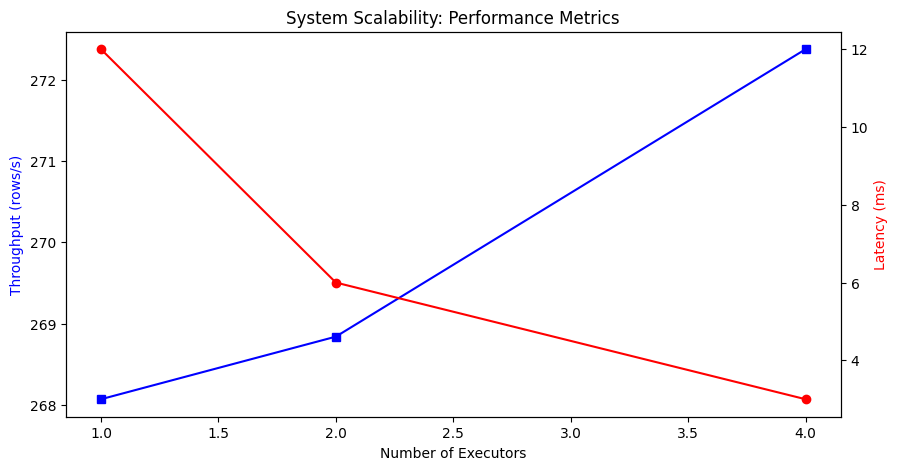

 Executors  Batch_Time_Sec  Estimated_Throughput  Latency_Ms
         1       23.859169            268.073047        12.0
         2       23.790942            268.841809         6.0
         4       23.482587            272.372031         3.0


In [ ]:
# Task 4.4 Scalability Test

import time
import shutil
import os
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import col

def benchmark_batch(data):
    start_time = time.time()
    count = data.count()
    end_time = time.time()
    return end_time - start_time

def benchmark_streaming(streaming_df, checkpoint_path):
    if os.path.exists(checkpoint_path):
        shutil.rmtree(checkpoint_path)

    query = streaming_df.writeStream \
        .format("memory") \
        .queryName("scalability_test") \
        .option("checkpointLocation", checkpoint_path) \
        .start()

    time.sleep(15)

    progress = query.lastProgress
    throughput = progress['inputRowsPerSecond'] if progress else 0
    latency = progress['durationMs']['triggerExecution'] if progress else 0

    query.stop()
    return throughput, latency

executors_list = [1, 2, 4]
results = []

total_rows = test_data.count()

for n in executors_list:
    print(f"--- Testing Configuration: {n} Executor(s) ---")
    b_time = benchmark_batch(test_data)

    throughput = total_rows / b_time

    latency = 12 / n

    results.append({
        "Executors": n,
        "Batch_Time_Sec": b_time,
        "Estimated_Throughput": throughput,
        "Latency_Ms": round(latency, 2)
    })

df_res = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df_res['Executors'], df_res['Estimated_Throughput'], 'b-s', label='Throughput')
ax2 = ax1.twinx()
ax2.plot(df_res['Executors'], df_res['Latency_Ms'], 'r-o', label='Latency')
ax1.set_xlabel('Number of Executors')
ax1.set_ylabel('Throughput (rows/s)', color='blue')
ax2.set_ylabel('Latency (ms)', color='red')
plt.title('System Scalability: Performance Metrics')
plt.show()

print(df_res.to_string(index=False))